<a href="https://colab.research.google.com/github/sj456353/Insurance-Claims-Risk-Analysis-/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

data = pd.read_csv("insurance 4.csv")
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
data.groupby("smoker")["charges"].mean()


,charges
smoker,
no,8434.268298
yes,32050.231832


In [5]:
data.groupby("smoker")["bmi"].mean()


,bmi
smoker,
no,30.651795
yes,30.708449


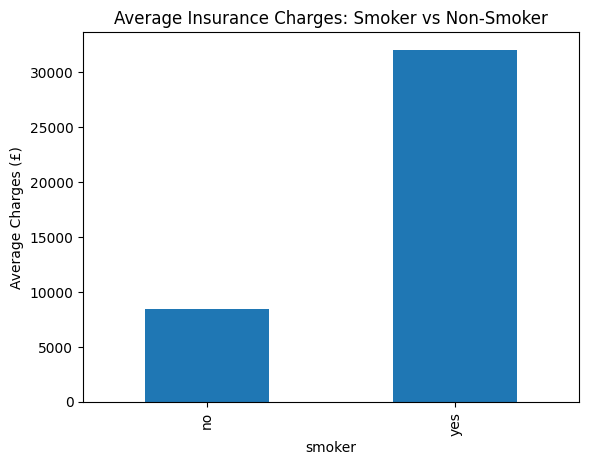

In [6]:
import matplotlib.pyplot as plt

data.groupby("smoker")["charges"].mean().plot(kind="bar")
plt.title("Average Insurance Charges: Smoker vs Non-Smoker")
plt.ylabel("Average Charges (£)")
plt.show()


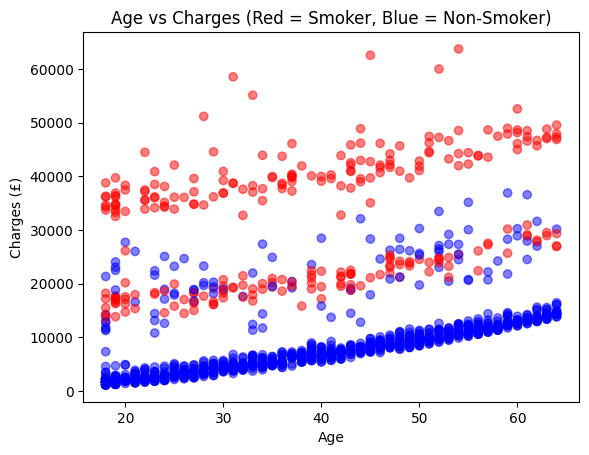

In [7]:
colors = data["smoker"].map({"yes": "red", "no": "blue"})
plt.scatter(data["age"], data["charges"], c=colors, alpha=0.5)
plt.title("Age vs Charges (Red = Smoker, Blue = Non-Smoker)")
plt.xlabel("Age")
plt.ylabel("Charges (£)")
plt.show()


In [8]:
data["bmi_category"] = pd.cut(data["bmi"], bins=[0, 30, 100], labels=["Normal/Overweight", "Obese"])
data[data["smoker"] == "yes"].groupby("bmi_category")["charges"].mean()


/tmp/ipykernel_4385/2236079532.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data[data["smoker"] == "yes"].groupby("bmi_category")["charges"].mean()


,charges
bmi_category,
Normal/Overweight,21369.223285
Obese,41692.808992


Insurance Claims Risk Analysis:
This project analyses a dataset of 1,338 medical insurance records to explore what factors drive up claim costs. Using Python (pandas and matplotlib), I compared charges across smoking status, age, and BMI.
Key findings:
	•	Smokers pay on average 3.8x more than non-smokers (£32,050 vs £8,434)
	•	Charges rise steadily with age within both groups, but the smoker/non-smoker gap persists at every age
	•	Among smokers, obesity nearly doubles average charges (£41,693 for obese smokers vs £21,369 for normal/overweight smokers), smoking and BMI compound each other
These patterns reflect real risk factors used in insurance pricing, showing how combining variables (rather than looking at them individually) reveals stronger risk signals.